## Common Test I. Multi-Class Classification (ResNet50 Transfer Learning)

**Name:** Potla Naga Sai Bharath  
**Gmail:** saibharathpotla29@gmail.com  

**Task:** Build a model for classifying the images into lenses using PyTorch or Keras. Pick the most appropriate approach and discuss your strategy.

**Dataset Description:** The dataset consists of three classes  strong lensing images with no substructure (`no`), subhalo substructure (`sphere`), and vortex substructure (`vort`). Images are stored as `.npy` files of shape `(1, 150, 150)`, pre-normalized using min-max normalization. Images are resized to `150×150` and converted to RGB for compatibility with the pretrained ResNet50 backbone.

**Evaluation Metrics:** ROC curve (Receiver Operating Characteristic curve) and AUC score (Area Under the ROC Curve), computed per-class and averaged as Macro AUC.

Trained model weights for this task can be found in the respective folder https://drive.google.com/file/d/140DJ1sw1q0pBokQb5B6FdtnZjvYhrhYI/view?usp=sharing

---

## Strategy

* The pretrained **ResNet50** backbone (ImageNet weights) is used as a frozen feature extractor  all convolutional layers up to the final pooling layer are retained and the original classification head is removed, preserving the rich low- and mid-level visual representations learned on ImageNet.

* The flattened feature map of shape `2048 × 5 × 5` is passed through a custom three-stage classification head, each stage consisting of `BatchNorm1d → Linear → ReLU → Dropout(0.2)`, progressively reducing dimensionality from 51200 → 128 → 64 → 3 with batch normalisation at each stage to stabilise training and dropout to regularise against overfitting.

* A final linear layer with 3 outputs produces raw logits, which are passed through `softmax` during inference to obtain per-class probabilities for the three lensing categories.

* Multi-GPU training is supported via `nn.DataParallel`, automatically distributing batches across all available GPUs, with checkpoint saving correctly handling the `.module` unwrapping for DataParallel models.

* Aggressive data augmentation is applied during training to improve generalisation  including random rotation (±180°), random affine translation (±20% of image size), random scaling (0.8×–1.2×), and random horizontal and vertical flips  reflecting the rotational symmetry of gravitational lensing images where no canonical orientation exists.

* Validation images receive only resizing and tensor conversion, ensuring clean and unbiased evaluation.

* The model is trained for 50 epochs using the Adam optimizer (lr = 1e-4) with CrossEntropyLoss. A `ReduceLROnPlateau` scheduler (factor = 0.7, patience = 4) monitors validation Macro AUC and reduces the learning rate when improvement stalls, with a minimum lr floor of 1e-5.

* The best model checkpoint is tracked and saved based on peak validation Macro AUC across all epochs, ensuring the final model reflects the best generalisation performance rather than the last epoch.

* Per-class AUC scores are computed via one-vs-rest ROC analysis using `sklearn.metrics.roc_curve`, and a Macro AUC is derived by averaging across all three classes  providing a balanced evaluation metric robust to any class imbalance.

---

## Results

The best model checkpoint was reloaded and evaluated on the full validation set:

| Metric | Value |
|:---|:---:|
| Validation Loss  | 0.1543 |
| Validation Accuracy  | 94.49% |
| Macro AUC  | 0.9917 |
| AUC — No Substructure  | 0.9918 |
| AUC — Subhalo (Sphere)  | 0.9864 |
| AUC — Vortex  | 0.9969 |



In [2]:
import os
import copy
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import functional as TF

from sklearn.metrics import confusion_matrix, roc_curve, auc
from tqdm import tqdm

warnings.filterwarnings("ignore")

In [3]:
data_directory_training = "/kaggle/input/datasets/nagasaibharathpotla/task-1/dataset/train"
data_directory_validation = "/kaggle/input/datasets/nagasaibharathpotla/task-1/dataset/val"

classes = ["no", "sphere", "vort"]
num_classes = 3

image_size = 150
batch_size = 256
num_epochs = 50
learning_rate = 1e-4
num_workers = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()

print("Using device:", device)
print("Number of GPUs available:", num_gpus)
for i in range(num_gpus):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

Using device: cuda
Number of GPUs available: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [4]:
class NPYImageDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
        self.samples = []

        for cls_name in classes:
            class_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(class_dir):
                continue

            for fname in os.listdir(class_dir):
                if fname.endswith(".npy"):
                    fpath = os.path.join(class_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((fpath, label))

        print(f"Loaded {len(self.samples)} samples from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]

        img = np.load(file_path)
        img = np.squeeze(img)

        if img.ndim != 2:
            raise ValueError(f"Unexpected image shape {img.shape} in {file_path}")

        img = np.uint8(img * 255)
        pil_img = Image.fromarray(img).convert("RGB")

        if self.transform is not None:
            pil_img = self.transform(pil_img)

        return pil_img, label

In [5]:
class CustomTrainTransform:
    def __init__(self, image_size=150):
        self.image_size = image_size

    def __call__(self, img):
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)

        angle = random.uniform(-180, 180)
        img = TF.rotate(img, angle)

        max_shift = 0.2
        max_dx = max_shift * self.image_size
        max_dy = max_shift * self.image_size
        translate = (random.uniform(-max_dx, max_dx), random.uniform(-max_dy, max_dy))
        scale = random.uniform(0.8, 1.2)

        img = TF.affine(
            img,
            angle=0.0,
            translate=(int(translate[0]), int(translate[1])),
            scale=scale,
            shear=0.0
        )

        if random.random() < 0.5:
            img = TF.hflip(img)

        if random.random() < 0.5:
            img = TF.vflip(img)

        img = TF.to_tensor(img)
        return img


class CustomValTransform:
    def __init__(self, image_size=150):
        self.image_size = image_size

    def __call__(self, img):
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        img = TF.to_tensor(img)
        return img

In [6]:
train_transform = CustomTrainTransform(image_size=image_size)
val_transform = CustomValTransform(image_size=image_size)

train_dataset = NPYImageDataset(
    root_dir=data_directory_training,
    classes=classes,
    transform=train_transform
)

val_dataset = NPYImageDataset(
    root_dir=data_directory_validation,
    classes=classes,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

Loaded 30000 samples from /kaggle/input/datasets/nagasaibharathpotla/task-1/dataset/train
Loaded 7500 samples from /kaggle/input/datasets/nagasaibharathpotla/task-1/dataset/val


In [7]:
class ResNet50Custom(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        self.features = nn.Sequential(*list(base.children())[:-2])
        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(2048 * 5 * 5),
            nn.Linear(2048 * 5 * 5, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.BatchNorm1d(64),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [8]:
model = ResNet50Custom(num_classes=num_classes)

if num_gpus > 1:
    print(f"Using DataParallel on {num_gpus} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


Using DataParallel on 2 GPUs
DataParallel(
  (module): ResNet50Custom(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.7,
    patience=4,
    min_lr=1e-5
)

In [10]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [11]:
def validate_one_epoch(model, dataloader, criterion, device, num_classes):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Validation", leave=False)

        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)

    return epoch_loss, epoch_acc, all_labels, all_probs, all_preds

In [12]:
def compute_multiclass_auc(y_true, y_probs, num_classes):
    y_true_bin = np.eye(num_classes)[y_true]

    auc_scores = {}
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        auc_scores[i] = auc(fpr, tpr)

    macro_auc = np.mean(list(auc_scores.values()))
    return auc_scores, macro_auc

In [13]:
def save_checkpoint(model, optimizer, epoch, best_val_auc, path):
    model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model_state,
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_auc": best_val_auc
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved: {path}")

In [14]:
best_val_auc = -1.0
best_model_wts = copy.deepcopy(
    model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
)

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
val_auc_history = []
lr_history = []

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, y_true, y_probs, y_pred = validate_one_epoch(
        model, val_loader, criterion, device, num_classes
    )

    auc_scores, macro_auc = compute_multiclass_auc(y_true, y_probs, num_classes)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    val_auc_history.append(macro_auc)
    lr_history.append(optimizer.param_groups[0]["lr"])

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Val   AUC : {macro_auc:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.8f}")

    scheduler.step(macro_auc)

    if macro_auc > best_val_auc:
        best_val_auc = macro_auc
        best_model_wts = copy.deepcopy(
            model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        )
        save_checkpoint(model, optimizer, epoch + 1, best_val_auc, "best_model_checkpoint.pth")
        print("Best model updated.")

print("\nTraining complete.")
print(f"Best Validation AUC: {best_val_auc:.4f}")


Epoch [1/50]


Train Loss: 1.1302 | Train Acc: 0.3602
Val   Loss: 1.1406 | Val   Acc: 0.3352
Val   AUC : 0.5741
Learning Rate: 0.00010000
Checkpoint saved: best_model_checkpoint.pth
Best model updated.

Epoch [2/50]


Train Loss: 1.0355 | Train Acc: 0.4517
Val   Loss: 1.0577 | Val   Acc: 0.4912
Val   AUC : 0.7509
Learning Rate: 0.00010000
Checkpoint saved: best_model_checkpoint.pth
Best model updated.

Epoch [3/50]


Train Loss: 0.8297 | Train Acc: 0.6194
Val   Loss: 0.7187 | Val   Acc: 0.6928
Val   AUC : 0.8754
Learning Rate: 0.00010000
Checkpoint saved: best_model_checkpoint.pth
Best model updated.

Epoch [4/50]


Train Loss: 0.6956 | Train Acc: 0.7012
Val   Loss: 0.5400 | Val   Acc: 0.7815
Val   AUC : 0.9252
Learning Rate: 0.00010000
Checkpoint saved: best_model_checkpoint.pth
Best model updated.

Epoch [5/50]


...

Train Loss: 0.2412 | Train Acc: 0.9105
Val   Loss: 0.1732 | Val   Acc: 0.9397
Val   AUC : 0.9901
Learning Rate: 0.00007000

Epoch [47/50]


Train Loss: 0.2291 | Train Acc: 0.9161
Val   Loss: 0.1862 | Val   Acc: 0.9324
Val   AUC : 0.9895
Learning Rate: 0.00004900

Epoch [48/50]


Train Loss: 0.2281 | Train Acc: 0.9160
Val   Loss: 0.1746 | Val   Acc: 0.9376
Val   AUC : 0.9906
Learning Rate: 0.00004900

Epoch [49/50]


Train Loss: 0.2226 | Train Acc: 0.9196
Val   Loss: 0.1680 | Val   Acc: 0.9419
Val   AUC : 0.9913
Learning Rate: 0.00004900
Checkpoint saved: best_model_checkpoint.pth
Best model updated.

Epoch [50/50]


Train Loss: 0.2194 | Train Acc: 0.9195
Val   Loss: 0.1543 | Val   Acc: 0.9449
Val   AUC : 0.9917
Learning Rate: 0.00004900
Checkpoint saved: best_model_checkpoint.pth
Best model updated.

Training complete.
Best Validation AUC: 0.9917


In [15]:
if isinstance(model, nn.DataParallel):
    model.module.load_state_dict(best_model_wts)
else:
    model.load_state_dict(best_model_wts)

model.eval()
print("Best model weights loaded.")

Best model weights loaded.


In [16]:
val_loss, val_acc, y_true, y_probs, y_pred = validate_one_epoch(
    model, val_loader, criterion, device, num_classes
)

auc_scores, macro_auc = compute_multiclass_auc(y_true, y_probs, num_classes)

print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Final Validation Macro AUC: {macro_auc:.4f}")

for i, cls_name in enumerate(classes):
    print(f"AUC ({cls_name}) = {auc_scores[i]:.4f}")

Final Validation Loss: 0.1543
Final Validation Accuracy: 0.9449
Final Validation Macro AUC: 0.9917
AUC (no) = 0.9918
AUC (sphere) = 0.9864
AUC (vort) = 0.9969


Confusion Matrix:
[[2487    2   11]
 [ 231 2183   86]
 [  42   41 2417]]


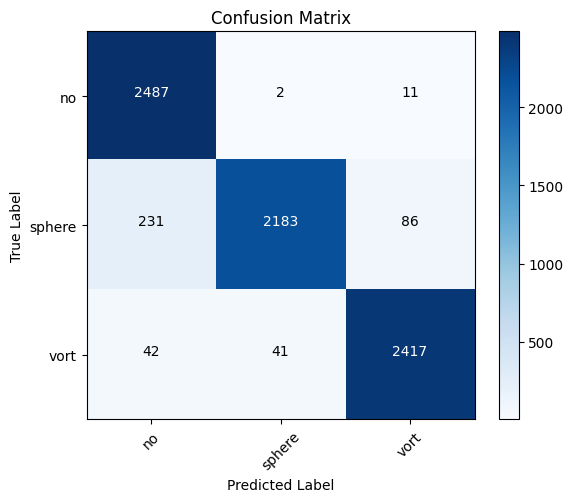

In [17]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

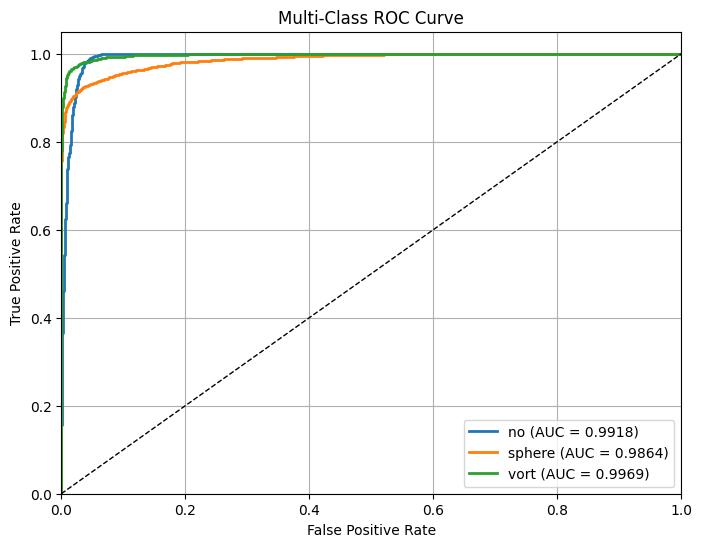

In [18]:
y_true_bin = np.eye(num_classes)[y_true]

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{classes[i]} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()